# PANAGEA exploration 3 — Remote-sensing reflectance (Rrs)

The shape and variability of the in-situ Rrs spectra, how many wavelengths
each observation carries, and the classic blue-to-green band-ratio vs
chlorophyll relationship that underpins ocean-colour algorithms.

Findings are summarised at the bottom.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ocpy.insitu import panagea

rrs = panagea.load('rrs')
meta = panagea.column_metadata(rrs)
spec_cols = [(n, m['wavelength']) for n, m in meta.items()
             if m.get('variable') == 'rrs' and m.get('role') == 'spectral']
spec_cols.sort(key=lambda t: t[1])
names = [n for n, _ in spec_cols]
waves = np.array([w for _, w in spec_cols])
print('%d Rrs wavelengths, %.0f-%.0f nm' %
      (len(waves), waves.min(), waves.max()))

948 Rrs wavelengths, 313-1022 nm


## How many wavelengths per spectrum?

The compilation mixes multispectral and hyperspectral instruments.

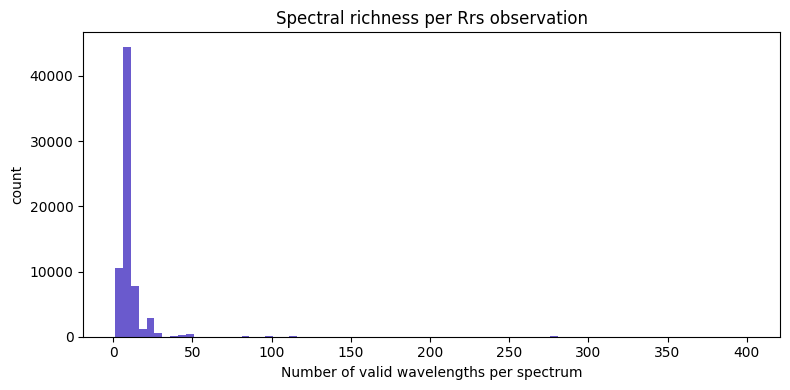

median 7, max 401 points per spectrum


In [2]:
nper = rrs[names].notna().sum(axis=1)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(nper[nper > 0], bins=80, color='slateblue')
ax.set_xlabel('Number of valid wavelengths per spectrum')
ax.set_ylabel('count')
ax.set_title('Spectral richness per Rrs observation')
plt.tight_layout(); plt.show()
print('median %d, max %d points per spectrum' %
      (int(nper.median()), int(nper.max())))

## Mean Rrs spectrum with variability

Median and inter-quartile band over the visible range.

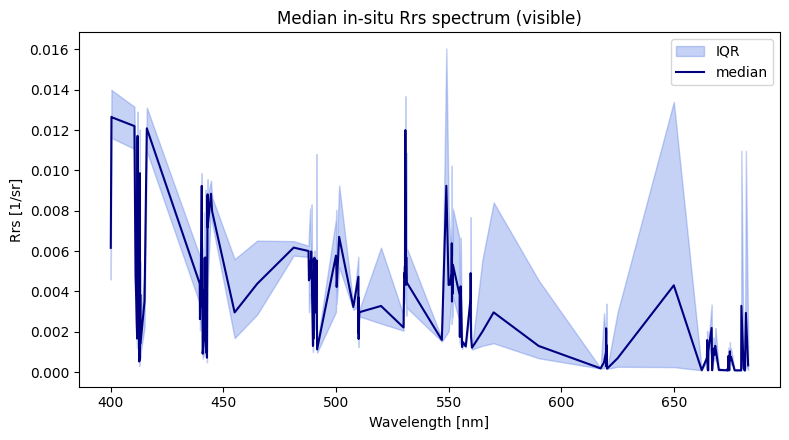

In [3]:
vis = (waves >= 400) & (waves <= 700)
arr = rrs[names].to_numpy(dtype=float)[:, vis]
w_vis = waves[vis]
# Require a wavelength to have enough samples to be meaningful.
n_ok = np.isfinite(arr).sum(axis=0)
keep = n_ok >= 200
q25, q50, q75 = np.nanpercentile(arr[:, keep], [25, 50, 75], axis=0)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.fill_between(w_vis[keep], q25, q75, alpha=0.3, color='royalblue',
                label='IQR')
ax.plot(w_vis[keep], q50, color='navy', label='median')
ax.set_xlabel('Wavelength [nm]'); ax.set_ylabel('Rrs [1/sr]')
ax.set_title('Median in-situ Rrs spectrum (visible)')
ax.legend()
plt.tight_layout(); plt.show()

## Band ratio vs chlorophyll

The basis of empirical chlorophyll algorithms: Rrs(blue)/Rrs(green) should
fall as chlorophyll rises. We join Rrs to the chlorophyll table on `ID`.

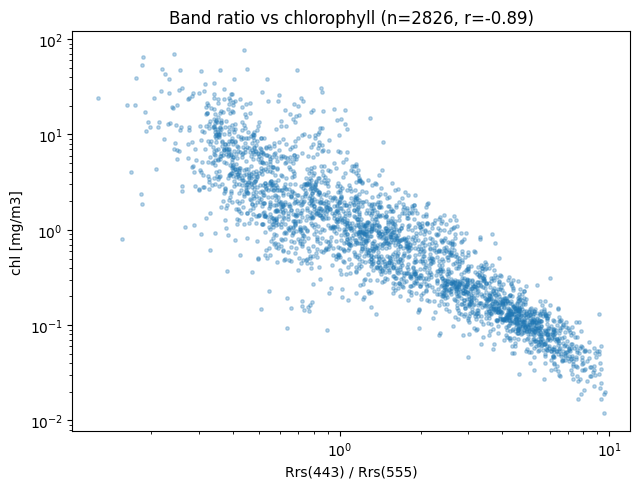

log-log correlation = -0.892


In [4]:
def nearest(target):
    return names[int(np.argmin(np.abs(waves - target)))]

blue, green = rrs[nearest(443)], rrs[nearest(555)]
ratio = blue / green

chla = panagea.load('chla')
chl = chla['chla_hplc'].fillna(chla['chla_fluor'])
m = pd.DataFrame({'ratio': ratio}).join(chl.rename('chl'), how='inner')
m = m.dropna()
m = m[(m['ratio'] > 0) & (m['chl'] > 0)]
r = np.corrcoef(np.log10(m['ratio']), np.log10(m['chl']))[0, 1]

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(m['ratio'], m['chl'], s=6, alpha=0.3)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Rrs(443) / Rrs(555)'); ax.set_ylabel('chl [mg/m3]')
ax.set_title('Band ratio vs chlorophyll (n=%d, r=%.2f)' % (len(m), r))
plt.tight_layout(); plt.show()
print('log-log correlation = %.3f' % r)

## Findings — Rrs

* **Mixed spectral resolution.** The median observation carries only ~7
  valid wavelengths (multispectral instruments), but the tail extends to
  ~400 wavelengths (hyperspectral) — so the table holds both classes.
* **Expected spectral shape.** The median Rrs spectrum peaks in the blue
  (~410-440 nm, ~0.007 1/sr) and falls steadily into the red (~0.0005 1/sr
  at 670 nm), with a wide inter-quartile spread reflecting the global mix of
  clear and turbid/productive waters.
* **Strong band-ratio relationship.** Rrs(443)/Rrs(555) is tightly,
  negatively correlated with chlorophyll (log-log r ~= -0.89). This
  reproduces the physical basis of OC-type algorithms directly from the
  in-situ data and confirms the cross-dataset `ID` join is sound.